In [1]:
import pandas as pd 
import numpy as np
import os 
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator

In [2]:
df = pd.read_csv("ai_chorales.csv")

In [78]:
df.shape

(340, 17)

# Data prep

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%dT%H-%M-%S-%fZ", utc=True)

In [4]:
df.head()

,participant_id,timestamp,age,musical_experience,plays_instrument,sings_in_choir,uses_ai_weekly,confidence_before,confidence_after,difficulty,free_feedback,stimulus,response,correct,correct_response,rt,training
0,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/153.5-3.wav,x,m,False,9871,False
1,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/256-5.wav,m,m,True,7578,False
2,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/227.11-5.wav,m,m,True,9041,False
3,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/H/122.6-4.wav,x,m,False,9712,False
4,e5258291-adb0-4836-96ef-3b394e48b230,2026-05-13 13:35:31.230000+00:00,20,erfahren,ja,nein,ja,unsicher,unsicher,sehr schwer,Ich kenne die Bachchoräle zwar nicht super gut...,data/A/output48-2.wav,x,x,True,8551,False


In [36]:
df = df[[
    'participant_id', 
    'timestamp',
    'age',
    'musical_experience',
    'plays_instrument',
    'sings_in_choir',
    'uses_ai_weekly',
    'confidence_before',
    'confidence_after',
    'difficulty',
    # free_feedback,
    'stimulus',
    'response',  
    'correct',
    'correct_response',
    'rt', 
    # 'training',
        ]]

In [ ]:
df["participant_id"].unique()

# Data eval

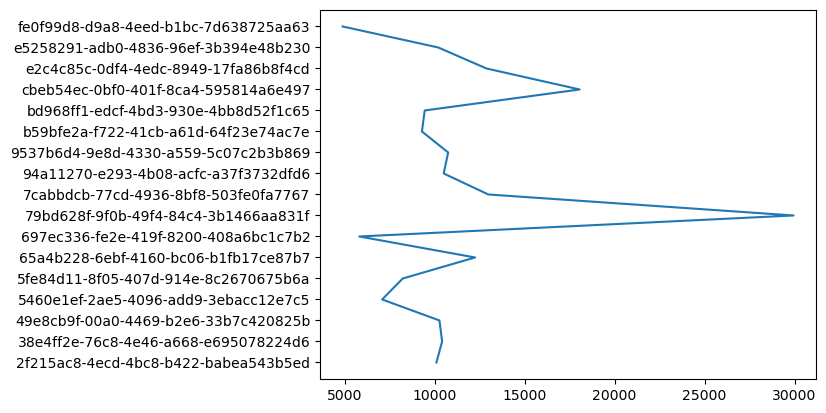

In [46]:
rt_sums = df.groupby(["participant_id", np.arange(len(df)) // 20])["rt"].sum().reset_index()


rt_sums.columns = ['participant_id', "", 'total_reaction_time']

rt_sums["average_rt"] = rt_sums["total_reaction_time"] / 20


plt.plot(
    rt_sums["average_rt"],
    rt_sums["participant_id"]
);

In [82]:
len(df["participant_id"].unique()) # => number of participants

17

Mean:  29.4
Median:  21.0


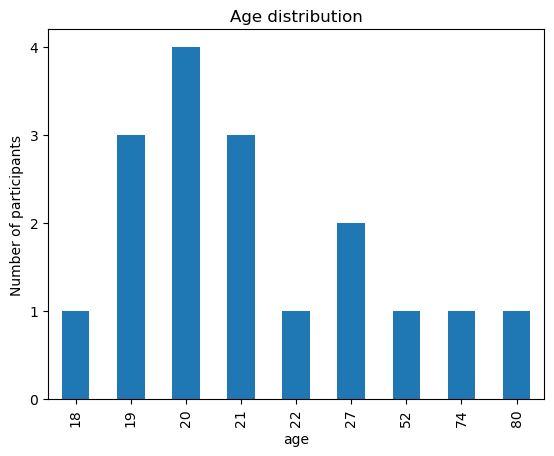

In [ ]:
# Age distribution

ages = df["age"]
age_values = ages.value_counts()

age_values = age_values / 20 # 20 columns per participant 

# create plot
age_values.sort_index().plot(kind="bar", ylabel="Number of participants", title="Age distribution")

# scale y axis to integers
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
print("Mean: ", round(ages.mean(), 1))
print("Median: ", ages.median())

plt.show()

Experience categories: ['ja', 'nein']
                count  mean  median
uses_ai_weekly                     
ja                 10  10.3    10.5
nein                7  11.0    11.0

Pearson correlation (category codes): 0.15487418760404845

Spearman correlation (category codes): 0.18596797250945302


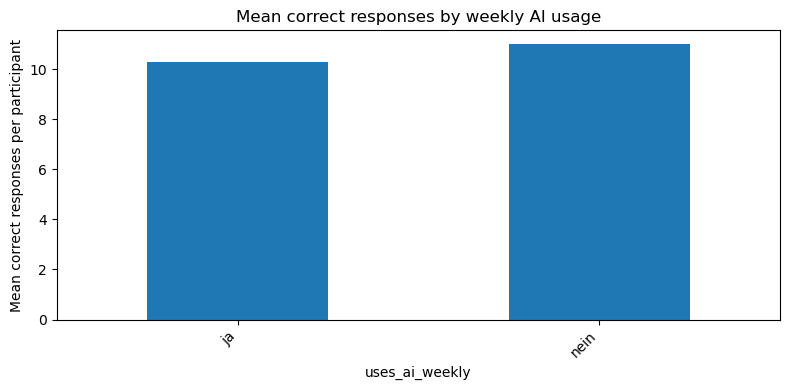

In [ ]:
# impact of AI usage on experiment result (vibecoded, might need to be revised)

participant_summary = (
    df.groupby(["participant_id", "uses_ai_weekly"], as_index=False)["correct_response"]
      .sum()
)
participant_summary["uses_ai_weekly"] = participant_summary["uses_ai_weekly"].astype("category")
participant_summary["experience_code"] = participant_summary["uses_ai_weekly"].cat.codes

print("Experience categories:", participant_summary["uses_ai_weekly"].cat.categories.tolist())
print(participant_summary.groupby("uses_ai_weekly", observed=True)["correct_response"].agg(["count", "mean", "median"]))

print("\nPearson correlation (category codes):",
      participant_summary["experience_code"].corr(participant_summary["correct_response"]))


print("\nSpearman correlation (category codes):",
      participant_summary["experience_code"].corr(participant_summary["correct_response"], method="spearman"))

_, ax = plt.subplots(figsize=(8, 4))
participant_summary.groupby("uses_ai_weekly", observed=True)["correct_response"].mean().plot(
    kind="bar", ax=ax
)
ax.set_ylabel("Mean correct responses per participant")
ax.set_title("Mean correct responses by weekly AI usage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

Experience categories: ['erfahren', 'sehr erfahren', 'sehr unerfahren', 'unerfahren']
                    count       mean  median
musical_experience                          
erfahren                7  10.714286    11.0
sehr erfahren           3  10.000000    11.0
sehr unerfahren         1   8.000000     8.0
unerfahren              6  11.166667    12.0

Pearson correlation (category codes): 0.06922327413251601

Spearman correlation (category codes): 0.2524142109008716


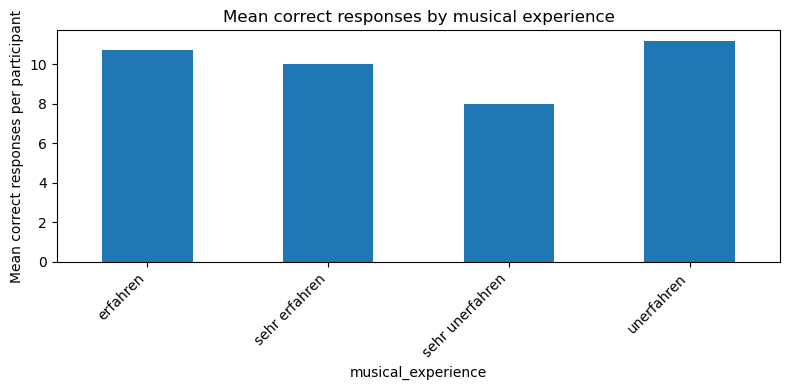

In [ ]:
# impact of musical experience on experiment result (vibecoded, might need to be revised)

participant_summary = (
    df.groupby(["participant_id", "musical_experience"], as_index=False)["correct_response"]
      .sum()
)
participant_summary["musical_experience"] = participant_summary["musical_experience"].astype("category")
participant_summary["experience_code"] = participant_summary["musical_experience"].cat.codes

print("Experience categories:", participant_summary["musical_experience"].cat.categories.tolist())
print(participant_summary.groupby("musical_experience", observed=True)["correct_response"].agg(["count", "mean", "median"]))

print("\nPearson correlation (category codes):",
      participant_summary["experience_code"].corr(participant_summary["correct_response"]))
print("\nSpearman correlation (category codes):",
      participant_summary["experience_code"].corr(participant_summary["correct_response"], method="spearman"))

_, ax = plt.subplots(figsize=(8, 4))
participant_summary.groupby("musical_experience", observed=True)["correct_response"].mean().plot(
    kind="bar", ax=ax
)
ax.set_ylabel("Mean correct responses per participant")
ax.set_title("Mean correct responses by musical experience")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

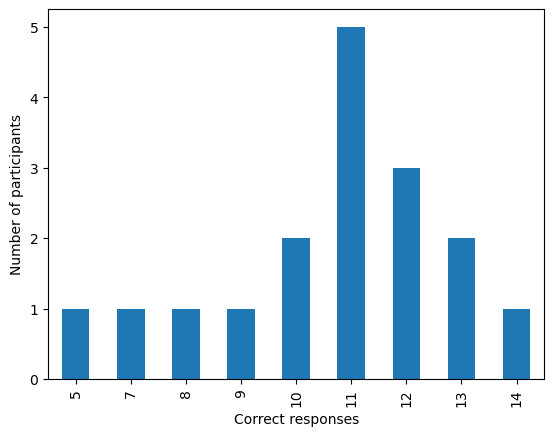

In [ ]:
# Correct response distribution

responses_indiv = pd.Series([g["correct_response"].sum() for n, g in df.groupby("timestamp") ])

responses_indiv.value_counts().sort_index().plot(kind="bar", xlabel="Correct responses", ylabel="Number of participants");



=> Approximately gaussian

Mean: 0.48128342245989303
Median:  0.47058823529411764


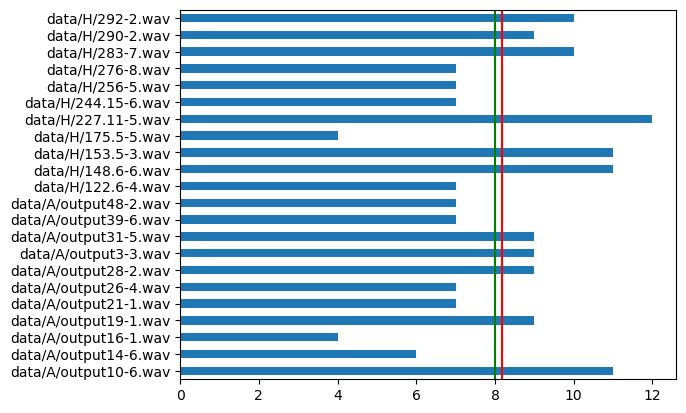

In [83]:
indices, values = zip(*[(n, g["correct_response"].sum()) for n, g in df.groupby("stimulus")])

responses_piece = pd.Series(values, index=indices).sort_index()

_, ax = plt.subplots()
responses_piece.plot(kind="barh", ax=ax)
avg = responses_piece.mean()
ax.axvline(avg, c="red")
ax.axvline(responses_piece.median(), c="green")
print("Mean:", responses_piece.mean() / 17)
print("Median: ", responses_piece.median() /17);

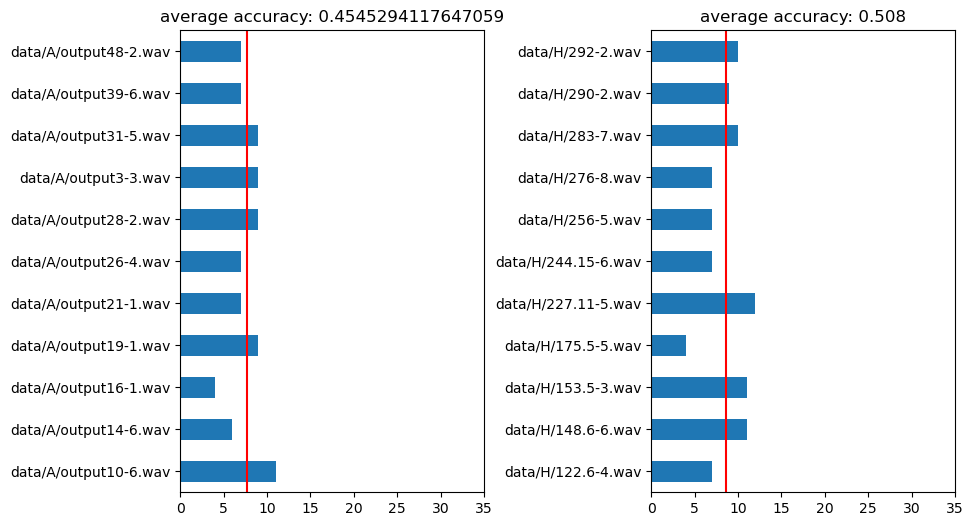

In [84]:
responses_A, responses_H = responses_piece[:11], responses_piece[11:]

_, axes = plt.subplots(1,2, figsize=(10,6), gridspec_kw={"wspace": .55})
for i, r in enumerate([responses_A, responses_H]):
    r.plot(kind="barh", ax=axes[i])
    avg = round(r.mean(), 3)
    axes[i].axvline(avg, c="red")
    axes[i].set_title(f"average accuracy: {avg/17}")
    axes[i].set_xlim(0,35)
    

**Notizen**

- Alle Beispiele von Menschen einspielen lassen? Oder besser erklären, dass alles maschinell ab gespielt wird.
- Vergleichen: Einspielung vs Synthetisch?
- Bach-Choräle beliebt zum Trainieren, aber wenig Kontakt für Schüler. Wie funktioniert es bei "zugänglicheren" Sachen?
- Frage erweitern: Kann KI-Musik von menschlicher unterscheiden? Ausweitung der Genres etc.
- Notentext einbeziehen? --> Hypothese: Aufgabe wird leichter
- Mit SCB durchführen (oder Choräle spielen lassen)